# TimeAtlas Quick Demo
Build a `TimeAtlas` from Ag1000G inference results (Burkina Faso + Cameroon) and explore the query API.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

sys.path.insert(0, str(Path(".").resolve().parent))
from fastcxt.atlas import TimeAtlas

RESULTS = Path("/tmp/het_results")
ARMS = ["2L", "2R", "3L", "3R", "X"]
GROUPS = {"2L": "2La_hom_standard", "2R": "2Rb_hom_standard", "3L": "all", "3R": "all", "X": "all"}
CLR = {"2L": "#2563eb", "2R": "#7c3aed", "3L": "#059669", "3R": "#d97706", "X": "#dc2626"}

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#fafafa",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

def load_arm(pop, arm, group, pt="intra", off=0):
    d = RESULTS / pop / arm / f"{group}_{pt}"
    if not d.exists(): return None, None, None, None
    m = np.load(d/"means.npz")["means"]; v = np.load(d/"variances.npz")["variances"]
    im = np.load(d/"index_map.npy"); bl = json.load(open(d/"blocks.json"))
    cfg = json.load(open(d/"config.json"))
    np_, nb, wpb = cfg["n_pairs"], len(bl), m.shape[1]; nt = nb*wpb
    pm, pv = np.zeros((np_,nt),np.float32), np.zeros((np_,nt),np.float32)
    for r in range(m.shape[0]):
        s = im[r,0]*wpb; pm[im[r,1],s:s+wpb]=m[r]; pv[im[r,1],s:s+wpb]=v[r]
    pairs = np.column_stack([np.arange(np_)+off, np.arange(np_)+off+10000]).astype(np.int32)
    ws = np.zeros(nt, np.int64)
    for b in bl:
        for w in range(wpb): ws[b["idx"]*wpb+w] = b["start"]+w*200
    return pm, pv, pairs, ws

def build_atlas(pop, off=0):
    a = TimeAtlas()
    for arm in ARMS:
        m,v,p,ws = load_arm(pop, arm, GROUPS[arm], off=off)
        if m is not None: a.add_arm(arm, m, v, p, ws, window_size=200, mutation_rate=3.5e-9)
    return a

bf = build_atlas("Burkina_Faso")
cm = build_atlas("Cameroon", off=5000)
print(bf, "\n", cm)

TimeAtlas(2L(2p x 246500w), 2R(4p x 307500w), 3L(50p x 209500w), 3R(50p x 265500w), X(50p x 121500w)) 
 TimeAtlas(2L(50p x 246500w), 2R(50p x 307500w), 3L(50p x 209500w), 3R(50p x 265500w), X(50p x 121500w))


### Genome-wide TMRCA landscape (all 5 arms)

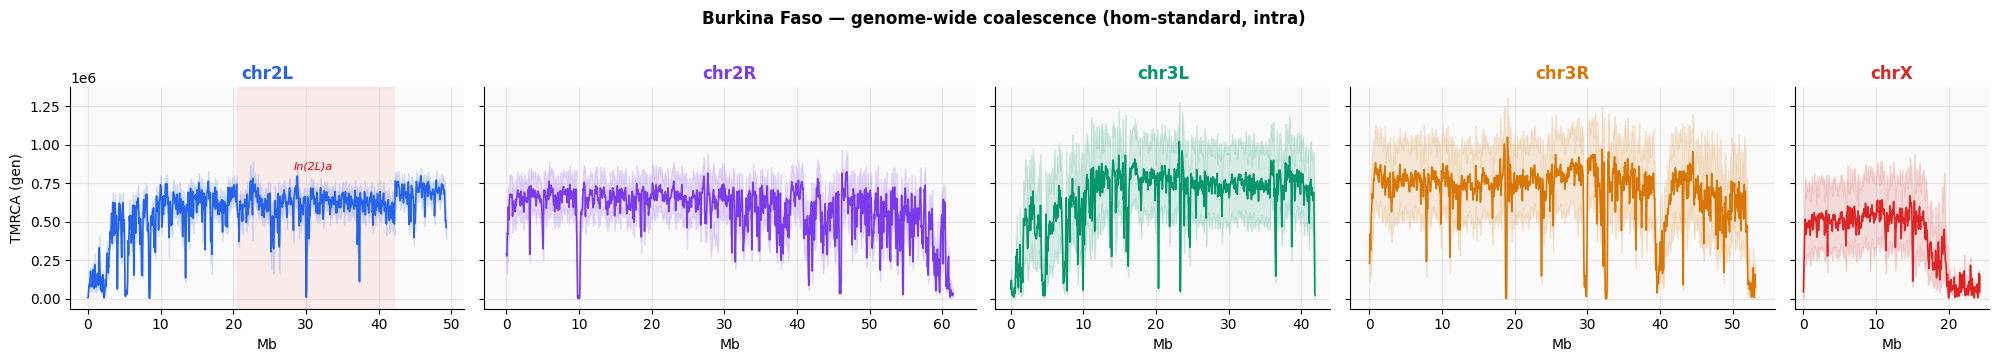

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5), sharey=True,
    gridspec_kw={"width_ratios": [bf.arms[a].n_windows for a in ARMS]})

for ax, arm in zip(axes, ARMS):
    ad = bf.arms[arm]; x = ad.window_starts/1e6; t = np.exp(ad.means)
    med = gaussian_filter1d(np.median(t, 0), 150)
    q25, q75 = [gaussian_filter1d(np.percentile(t, q, 0), 150) for q in (25,75)]
    ax.fill_between(x, q25, q75, color=CLR[arm], alpha=0.15)
    ax.plot(x, med, color=CLR[arm], lw=1.2)
    if arm == "2L":
        ax.axvspan(20.524, 42.165, color="red", alpha=0.06, zorder=0)
        ax.text(31, med.max()*1.05, "In(2L)a", color="red", fontsize=8, ha="center", style="italic")
    ax.set_title(f"chr{arm}", color=CLR[arm], fontweight="bold"); ax.set_xlabel("Mb")
axes[0].set_ylabel("TMRCA (gen)")
fig.suptitle("Burkina Faso — genome-wide coalescence (hom-standard, intra)", fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig("figures/atlas_landscape.png", dpi=150, bbox_inches="tight"); plt.show()

### TMRCA raster — 50 pairs x 42 Mb on chr3L

/var/folders/3s/hwl2l1l15mb9wgxw12hzdch80000gn/T/ipykernel_85621/3723569629.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig("figures/atlas_raster.png", dpi=150, bbox_inches="tight"); plt.show()


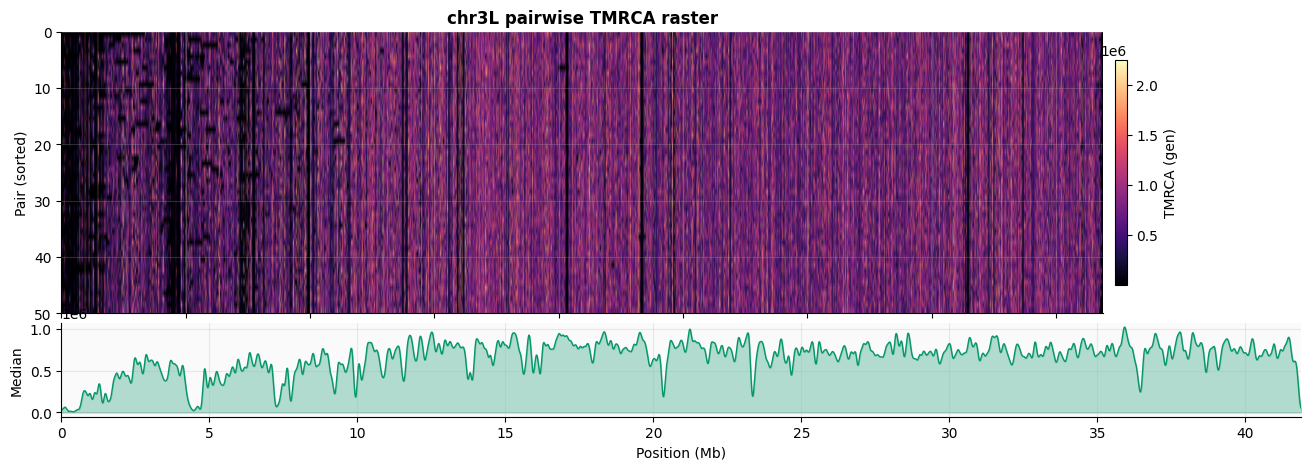

In [3]:
ad = bf.arms["3L"]; t = np.exp(ad.means); step = 50
td = t[np.argsort(t.mean(1)), ::step]; xm = ad.window_starts[::step]/1e6

fig, (ah, ap) = plt.subplots(2, 1, figsize=(16, 5), height_ratios=[3,1],
    sharex=True, gridspec_kw={"hspace": 0.05})
im = ah.imshow(td, aspect="auto", cmap="magma", extent=[xm[0],xm[-1],td.shape[0],0], interpolation="bilinear")
ah.set_ylabel("Pair (sorted)"); ah.set_title("chr3L pairwise TMRCA raster", fontweight="bold")
fig.colorbar(im, ax=ah, shrink=0.8, pad=0.01, label="TMRCA (gen)")
med = gaussian_filter1d(np.median(t[:,::step],0), 5)
ap.fill_between(xm, med, color=CLR["3L"], alpha=0.3); ap.plot(xm, med, color=CLR["3L"], lw=1)
ap.set_ylabel("Median"); ap.set_xlabel("Position (Mb)")
fig.tight_layout(); fig.savefig("figures/atlas_raster.png", dpi=150, bbox_inches="tight"); plt.show()

### Cross-arm mean TMRCA + BF vs Cameroon comparison

/var/folders/3s/hwl2l1l15mb9wgxw12hzdch80000gn/T/ipykernel_85621/938019227.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=[f"chr{a}" for a in ARMS], patch_artist=True, widths=0.5,


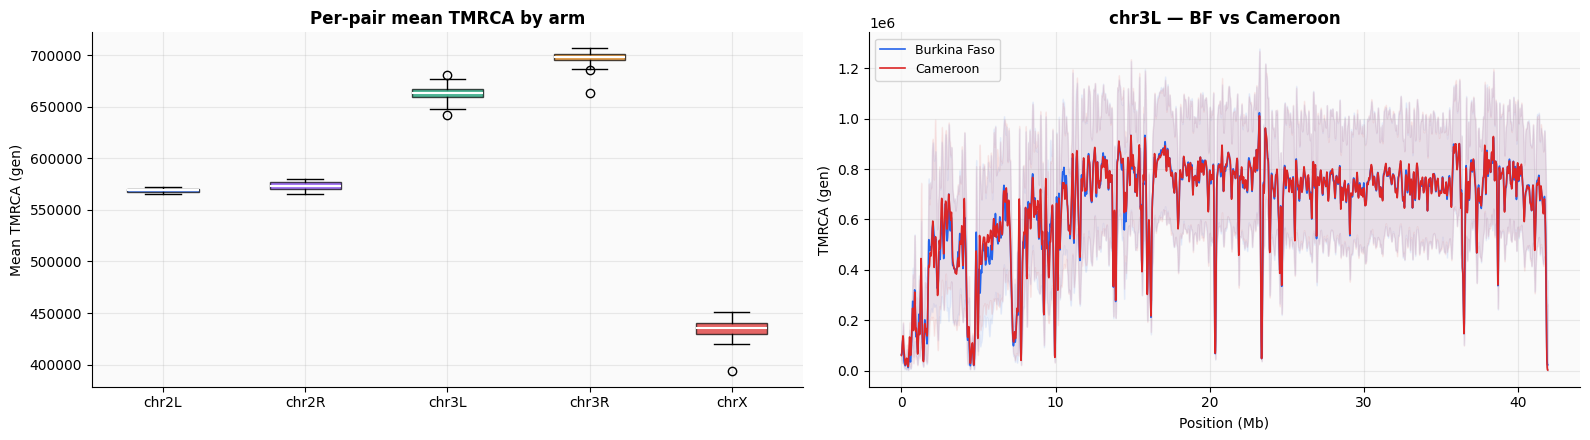

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

# left: boxplot across arms
data = [bf.mean_tmrca(a) for a in ARMS]
bp = ax1.boxplot(data, labels=[f"chr{a}" for a in ARMS], patch_artist=True, widths=0.5,
    medianprops=dict(color="white", lw=1.5))
for p, a in zip(bp["boxes"], ARMS): p.set_facecolor(CLR[a]); p.set_alpha(0.7)
ax1.set_ylabel("Mean TMRCA (gen)"); ax1.set_title("Per-pair mean TMRCA by arm", fontweight="bold")

# right: BF vs CM landscape on 3L
for lab, at, c in [("Burkina Faso", bf, "#2563eb"), ("Cameroon", cm, "#dc2626")]:
    ad = at.arms["3L"]; x = ad.window_starts/1e6; t = np.exp(ad.means)
    med = gaussian_filter1d(np.median(t,0), 150)
    q25, q75 = [gaussian_filter1d(np.percentile(t,q,0), 150) for q in (25,75)]
    ax2.fill_between(x, q25, q75, color=c, alpha=0.08)
    ax2.plot(x, med, color=c, lw=1.2, label=lab)
ax2.legend(fontsize=9); ax2.set_xlabel("Position (Mb)"); ax2.set_ylabel("TMRCA (gen)")
ax2.set_title("chr3L — BF vs Cameroon", fontweight="bold")

fig.tight_layout(); fig.savefig("figures/atlas_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### IICR demographic proxy + uncertainty along 2L

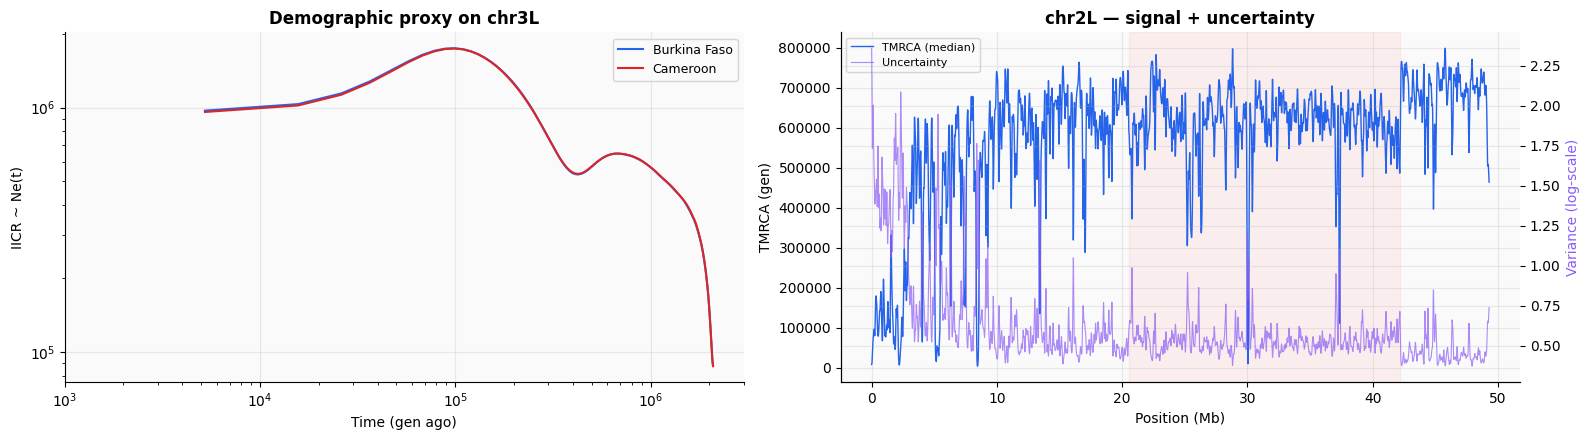

In [5]:
def iicr(atlas, arm, n_bins=200):
    t = np.exp(atlas.arms[arm].means).flatten(); t = t[t>0]
    edges = np.linspace(0, np.percentile(t,99.5), n_bins+1)
    c, w = (edges[:-1]+edges[1:])/2, np.diff(edges)
    h,_ = np.histogram(t, edges); surv = np.maximum(len(t)-np.cumsum(h)+h, 1)
    rate = (h/surv)/w; rate[rate<=0] = np.nan
    return c, 1.0/rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))

# left: IICR
for lab, at, c in [("Burkina Faso", bf, "#2563eb"), ("Cameroon", cm, "#dc2626")]:
    t, ne = iicr(at, "3L"); m = np.isfinite(ne)
    ne_s = ne.copy(); ne_s[m] = gaussian_filter1d(ne[m], 3)
    ax1.plot(t[m], ne_s[m], color=c, lw=1.5, label=lab)
ax1.set_xscale("log"); ax1.set_yscale("log"); ax1.set_xlim(1e3,3e6)
ax1.set_xlabel("Time (gen ago)"); ax1.set_ylabel("IICR ~ Ne(t)")
ax1.set_title("Demographic proxy on chr3L", fontweight="bold"); ax1.legend(fontsize=9)

# right: TMRCA + uncertainty on 2L
ad = bf.arms["2L"]; x = ad.window_starts/1e6
t = np.exp(ad.means); med = gaussian_filter1d(np.median(t,0), 150)
ax2.plot(x, med, color="#2563eb", lw=1, label="TMRCA (median)")
ax2b = ax2.twinx()
vm = gaussian_filter1d(np.median(ad.variances,0), 150)
ax2b.plot(x, vm, color="#8b5cf6", lw=0.8, alpha=0.7, label="Uncertainty")
ax2b.set_ylabel("Variance (log-scale)", color="#8b5cf6")
ax2.axvspan(20.524, 42.165, color="red", alpha=0.05)
ax2.set_xlabel("Position (Mb)"); ax2.set_ylabel("TMRCA (gen)")
ax2.set_title("chr2L — signal + uncertainty", fontweight="bold")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, fontsize=8)

fig.tight_layout(); fig.savefig("figures/atlas_iicr_uncert.png", dpi=150, bbox_inches="tight"); plt.show()